# Hungarian Dataset Simulation and Optimization

# ONLY ONE WEEK DATA

In [1]:
from utils import data_path, tech_colors, cost_params, week_numbers, seasons
from utils import plot_generator_t, plot_generator_t_plotly, change_costs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pypsa

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Create analyzed dates
- **week 15**: April 8 - April 14

In [2]:
dates = pd.date_range(start=pd.to_datetime('2000-01-01')+pd.Timedelta(weeks=14), 
                      end=pd.to_datetime('2000-01-01')+pd.Timedelta(weeks=14)+pd.Timedelta(days=6, hours=23),
                      freq='h').to_list()

# Import Data

In [3]:
potentials_generator = pd.read_excel(data_path, sheet_name='potentials_generator', index_col=0, na_values='None')
potentials_storage = pd.read_excel(data_path, sheet_name='potentials_storage', index_col=0, na_values='None')
costs_generator = pd.read_excel(data_path, sheet_name='costs_generator', index_col=0, na_values='None').to_dict()
costs_storage = pd.read_excel(data_path, sheet_name='costs_storage', index_col=0, na_values='None').to_dict()
profile_wind = pd.read_excel(data_path, sheet_name='profile_wind', names=list(week_numbers.keys()), header=None, index_col=0)['week_15']
profile_PV = pd.read_excel(data_path, sheet_name='profile_PV', names=list(week_numbers.keys()), header=None, index_col=0)['week_15']
demand = pd.read_excel(data_path, sheet_name='demand').values[:7].ravel()

In [4]:
change_costs(costs_generator, ['Nuclear'], ['operation'], 
             'linear', start=1, stop=5000, num=demand.shape[0])

# PyPSA - Network & Optimizations

- [Generator parameters](https://docs.pypsa.org/latest/api/components/types/generators/#pypsa.components.Generators.add) 
- [Storage Unit paramaters](https://docs.pypsa.org/latest/api/components/types/storage-units/#pypsa.components.StorageUnits.add)
    <!--     - `p_nom` / `p_nom_extendable`: nominális teljesítmény (korlátoztható/bővíthető)
    - `p_nom_min` / `p_nom_max` / `p_nom_set`
    - `p_min_pu` / `p_max_pu`: min input / max output for each snapshot
    --->




- [HiGHS](https://en.wikipedia.org/wiki/HiGHS_optimization_solver)

In [5]:
#potentials_generator.loc['ramp_up', 'Nuclear']=0.1
#potentials_generator.loc['ramp_down', 'Nuclear']=0.1

In [6]:
# Building the network
network = pypsa.Network(name='Network')

# Time stamps
snapshots = np.array(dates)
network.set_snapshots(list(snapshots))

# Base electrical network
network.add(class_name="Bus", 
            name="country_0",
            carrier='AC'
           )

# Set a carrier for the network
network.add(class_name='Carrier',
            name='AC'
           )

# Add demand to the network
network.add(class_name="Load", 
            name="Residential demand",  
            bus="country_0", 
            p_set=demand
           )   

# Add generators to the network
for technology in potentials_generator.keys(): 
    p_max_pu=1
    p_min_pu=0
    p_nom_extendable=True
    committable=False
    # getting profiles 
    if technology in ['Solar']:
        p_max_pu=np.tile(profile_PV.values, 7)  # type: ignore (VSCode warning)
    elif technology in ['Wind Onshore']:
        p_max_pu=np.tile(profile_wind.values, 7) # type: ignore (VSCode warning)
    elif technology in ['Fossil Lignite']:
        committable=True

    # adding generators
    network.add(class_name="Generator", 
                name=str(technology),
                bus="country_0",
                p_nom=potentials_generator.loc['p_nom'][str(technology)],
                p_nom_extendable=p_nom_extendable, # optimisable generator capacity
                p_nom_max=potentials_generator.loc['p_nom_max'][str(technology)], # maximum limit
                p_nom_min=potentials_generator.loc['p_nom_min'][str(technology)], # minimum limit
                
                capital_cost=costs_generator[str(technology)]['capital'], # generator installation cost
                marginal_cost=sum([costs_generator[str(technology)][key] for key in cost_params]), # operating cost
                p_max_pu=p_max_pu, # maximum power per-unit // production profiles
                p_min_pu=p_min_pu, # minimum power per-unit // production profiles
                #p_init=potentials_generator.loc['p_init'][str(technology)],
                
                ramp_limit_up=potentials_generator.loc['ramp_up'][str(technology)],   # maximum increase per hour
                ramp_limit_down=potentials_generator.loc['ramp_down'][str(technology)], # maximum decrease per hour

                committable=committable,
                ramp_limit_start_up=0.75,
                ramp_limit_shut_down=0.75
               )

# Storage units creation
for technology in potentials_storage.keys():
    network.add(class_name="StorageUnit", 
                name=str(technology),
                bus="country_0",
                
                p_nom_extendable=True, # optimisable storage capacity
                p_nom_max=potentials_storage.loc['p_nom_max'][str(technology)], # maximum limit
                capital_cost=costs_storage[str(technology)]['capital'], # installation cost
                marginal_cost=sum([costs_storage[str(technology)][key] for key in cost_params]), # operating cost
               )    

# Optimization
network.sanitize()
result = network.optimize(solver_name='highs', 
                          solver_options={'presolve':'on', 
                                          'threads':8,
                                          'log_to_console': True,
                                          'tolerance': 0.01,
                                          #'max_iterations': 1000,
                                          'time_limit': 500  # seconds
                                         }
                         )
result

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - presolve: on
 - threads: 8
 - log_to_console: True
 - tolerance: 0.01
 - time_limit: 500
INFO:linopy.io: Writing time: 1.01s


ERROR:   getOptionIndex: Option "tolerance" is unknown
Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-828i6jry has 12770 rows; 3712 cols; 30292 nonzeros; 504 integer variables (504 binary)
Coefficient ranges:
  Matrix  [8e-04, 6e+02]
  Cost    [1e-01, 4e+04]
  Bound   [1e+00, 7e+07]
  RHS     [1e+00, 6e+03]
Presolving model
6699 rows, 2641 cols, 18906 nonzeros 0s
5525 rows, 2138 cols, 16565 nonzeros 0s
5048 rows, 2138 cols, 15611 nonzeros 0s
Presolve reductions: rows 5048(-7722); columns 2138(-1574); nonzeros 15611(-14681) 

Solving MIP model with:
   5048 rows
   2138 cols (502 binary, 0 integer, 0 implied int., 1636 continuous, 0 domain fixed)
   15611 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS s

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: time_limit
Solution: 3712 primals, 12770 duals
Objective: 1.75e+07
Solver model: available
Solver message: Time limit reached



     11663     557      3229  99.98%   17413489.81877  17509869.05576     0.55%     4864    175   3011    970532   500.0s

Solving report
  Model             linopy-problem-828i6jry
  Status            Time limit reached
  Primal bound      17509869.0558
  Dual bound        17413489.8188
  Gap               0.55% (tolerance: 0.01%)
  P-D integral      10.8575243085
  Solution status   feasible
                    17509869.0558 (objective)
                    0 (bound viol.)
                    1.58603289232e-15 (int. viol.)
                    0 (row viol.)
  Timing            500.01
  Max sub-MIP depth 6
  Nodes             11663
  Repair LPs        0
  LP iterations     970532
                    236144 (strong br.)
                    29085 (separation)
                    56848 (heuristics)


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-status-p-fixed-upper, Generator-start_up-p-fixed-upper, Generator-shut_down-p-fixed-upper, Generator-ext-p-lower, Generator-ext-p-upper, Generator-com-ext-p-lower, Generator-com-ext-p-upper-bigM, Generator-com-ext-p-upper-cap, Generator-com-ext-p-lower-nonneg, Generator-com-transition-start-up, Generator-com-transition-shut-down, Generator-com-status-min_up_time_must_stay_up, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, Generator-p-ramp_limit_up-run-bigM, Generator-p-ramp_limit_up-start-bigM, Generator-p-ramp_limit_down-run-bigM, Generator-p-ramp_limit_down-shut-bigM, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'time_limit')

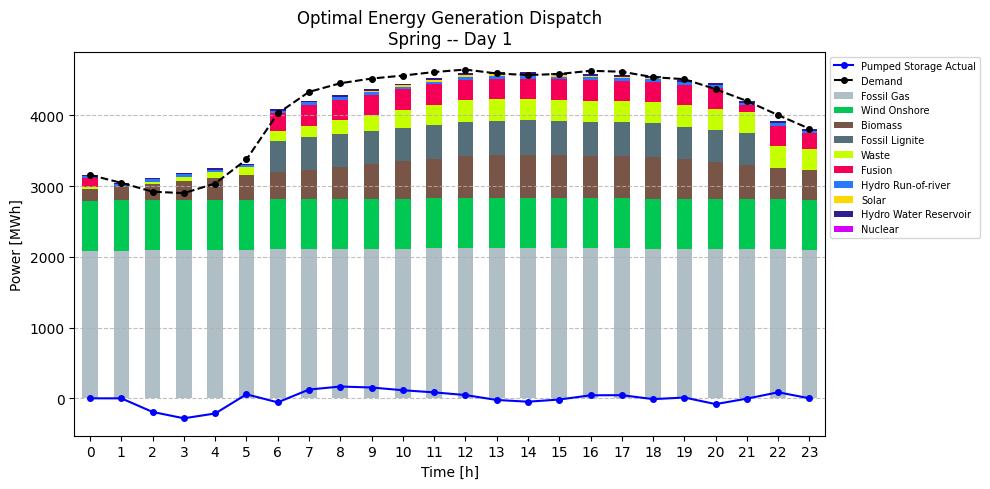

In [7]:
if result[0] == 'ok':
    plot_generator_t(network, [dates], season='Spring', day=1, colors=tech_colors, demand=demand)

In [8]:
_ = network.export_to_netcdf("data/power_network_HU_spring.nc")

INFO:pypsa.network.io:Exported network 'Network' saved to 'data/power_network_HU_spring.nc contains: generators, sub_networks, storage_units, carriers, loads, buses
